DBSCAN CLUSTERING

 STEP 1: Loading Data
----------------------------------------
 Data loaded successfully!
   Shape: (1025, 13)

 STEP 2: Finding Optimal eps (K-Distance Graph)
----------------------------------------


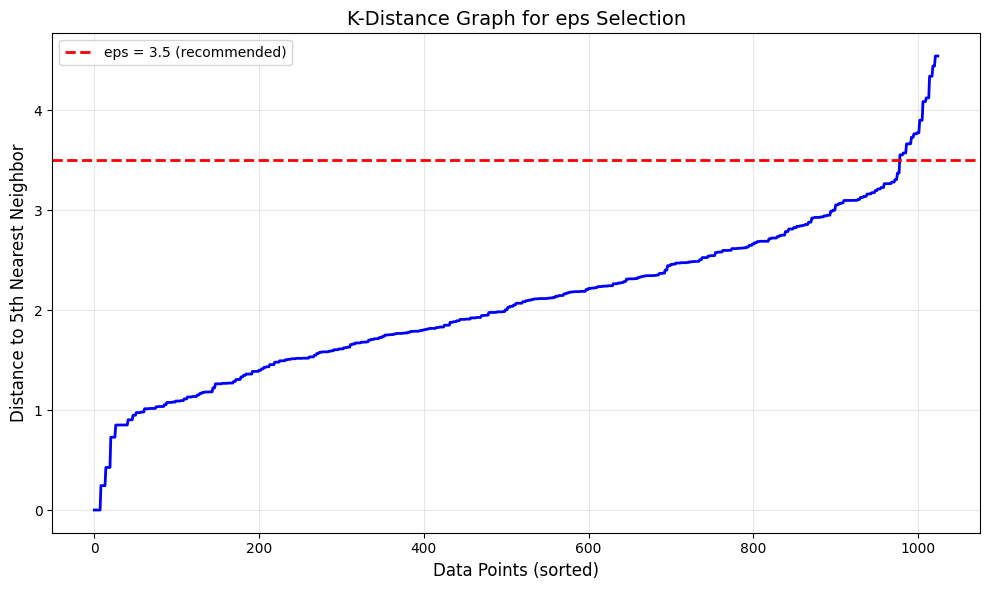

 Look for the 'elbow' (knee) in the graph
   Choose eps = value at the elbow

 STEP 3: Trying Different eps Values
----------------------------------------
   eps=2.0: Clusters=28, Noise=526
   eps=2.5: Clusters=6, Noise=290
   eps=3.0: Clusters=3, Noise=125
   eps=3.5: Clusters=1, Noise=47
   eps=4.0: Clusters=1, Noise=19
   eps=4.5: Clusters=1, Noise=4

 Best eps selected: 2.5

 STEP 4: Applying DBSCAN with Best Parameters
----------------------------------------

 Results:
   eps=2.5, min_samples=5
   Number of clusters: 6
   Number of noise points: 290 (28.3%)

 Cluster Distribution:
   Noise (-1): 290 patients (28.3%)
   Cluster 0: 678 patients (66.1%)
   Cluster 1: 25 patients (2.4%)
   Cluster 2: 7 patients (0.7%)
   Cluster 3: 7 patients (0.7%)
   Cluster 4: 10 patients (1.0%)
   Cluster 5: 8 patients (0.8%)

 Silhouette Score: -0.010
 Adjusted Rand Index: 0.036

 STEP 5: Visualizing DBSCAN Clusters
----------------------------------------


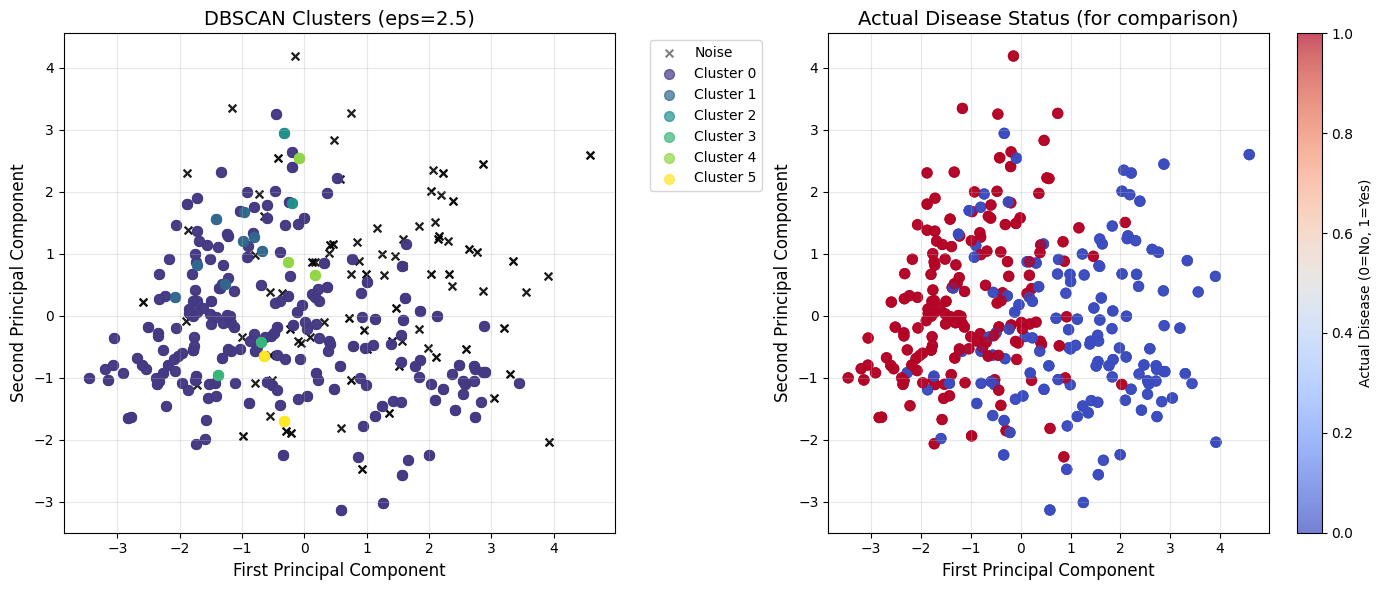


 STEP 6: Cluster Characteristics
----------------------------------------

 NOISE POINTS (290 patients):
   These patients don't fit well into any cluster
   Average Age: 57.8
   Disease Rate: 32.8%

 CLUSTER 0 (678 patients):
   Age: 53.0 years
   Heart Rate: 152.3 bpm
   Cholesterol: 242 mg/dl
   Disease Rate: 56.9%

 CLUSTER 1 (25 patients):
   Age: 55.2 years
   Heart Rate: 166.1 bpm
   Cholesterol: 208 mg/dl
   Disease Rate: 100.0%

 CLUSTER 2 (7 patients):
   Age: 56.3 years
   Heart Rate: 155.0 bpm
   Cholesterol: 306 mg/dl
   Disease Rate: 42.9%

 CLUSTER 3 (7 patients):
   Age: 47.9 years
   Heart Rate: 138.9 bpm
   Cholesterol: 198 mg/dl
   Disease Rate: 100.0%

 CLUSTER 4 (10 patients):
   Age: 57.2 years
   Heart Rate: 165.0 bpm
   Cholesterol: 245 mg/dl
   Disease Rate: 60.0%

 CLUSTER 5 (8 patients):
   Age: 52.0 years
   Heart Rate: 168.5 bpm
   Cholesterol: 234 mg/dl
   Disease Rate: 50.0%

 DBSCAN CLUSTERING COMPLETE!


In [3]:
"""
TASK 3: DBSCAN CLUSTERING
Density-Based Spatial Clustering - finds clusters of any shape
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DBSCAN CLUSTERING")
print("="*60)

# ============================================
# STEP 1: Load Data
# ============================================
print("\n STEP 1: Loading Data")
print("-"*40)

X_scaled = pd.read_csv('X_scaled.csv')
df_original = pd.read_csv('heart.csv')
y_true = df_original['target']

print(f" Data loaded successfully!")
print(f"   Shape: {X_scaled.shape}")

# ============================================
# STEP 2: Find Optimal eps using K-Distance Graph
# ============================================
print("\n STEP 2: Finding Optimal eps (K-Distance Graph)")
print("-"*40)

# Compute k-distance graph (k=5 for min_samples)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
k_distances = np.sort(distances[:, 4])  # 5th nearest neighbor

plt.figure(figsize=(10, 6))
plt.plot(k_distances, 'b-', linewidth=2)
plt.xlabel('Data Points (sorted)', fontsize=12)
plt.ylabel('Distance to 5th Nearest Neighbor', fontsize=12)
plt.title('K-Distance Graph for eps Selection', fontsize=14)
plt.axhline(y=3.5, color='red', linestyle='--', linewidth=2, label='eps = 3.5 (recommended)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_k_distance.png', dpi=150)
plt.show()

print(" Look for the 'elbow' (knee) in the graph")
print("   Choose eps = value at the elbow")

# ============================================
# STEP 3: Try Different eps Values
# ============================================
print("\n STEP 3: Trying Different eps Values")
print("-"*40)

eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
best_eps = None
best_n_clusters = 0

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)
    
    print(f"   eps={eps}: Clusters={n_clusters}, Noise={n_noise}")
    
    if n_clusters > best_n_clusters and n_clusters <= 8 and n_clusters > 1:
        best_n_clusters = n_clusters
        best_eps = eps

if best_eps is None:
    best_eps = 3.5

print(f"\n Best eps selected: {best_eps}")

# ============================================
# STEP 4: Apply DBSCAN with Best Parameters
# ============================================
print("\n STEP 4: Applying DBSCAN with Best Parameters")
print("-"*40)

best_min_samples = 5
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
clusters = dbscan.fit_predict(X_scaled)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"\n Results:")
print(f"   eps={best_eps}, min_samples={best_min_samples}")
print(f"   Number of clusters: {n_clusters}")
print(f"   Number of noise points: {n_noise} ({n_noise/len(clusters)*100:.1f}%)")

# Cluster distribution
print(f"\n Cluster Distribution:")
for i in sorted(set(clusters)):
    if i == -1:
        count = list(clusters).count(-1)
        print(f"   Noise (-1): {count} patients ({count/len(clusters)*100:.1f}%)")
    else:
        count = list(clusters).count(i)
        print(f"   Cluster {i}: {count} patients ({count/len(clusters)*100:.1f}%)")

# Calculate metrics (excluding noise for silhouette)
if n_clusters > 1:
    mask = clusters != -1
    sil_score = silhouette_score(X_scaled[mask], clusters[mask])
    print(f"\n Silhouette Score: {sil_score:.3f}")
else:
    print(f"\n Silhouette Score: Only {n_clusters} cluster found (can't compute)")

ari = adjusted_rand_score(y_true, clusters)
print(f" Adjusted Rand Index: {ari:.3f}")

# ============================================
# STEP 5: Visualize DBSCAN Clusters
# ============================================
print("\n STEP 5: Visualizing DBSCAN Clusters")
print("-"*40)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Plot 1: DBSCAN Clusters
plt.subplot(1, 2, 1)
unique_labels = sorted(set(clusters))
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'black'
        marker = 'x'
        label_name = 'Noise'
        s = 30
        alpha = 0.5
    else:
        marker = 'o'
        label_name = f'Cluster {label}'
        s = 50
        alpha = 0.7
    
    mask = clusters == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], marker=marker, 
                s=s, alpha=alpha, label=label_name)

plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title(f'DBSCAN Clusters (eps={best_eps})', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Plot 2: Actual Disease Status
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(scatter, label='Actual Disease (0=No, 1=Yes)')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('Actual Disease Status (for comparison)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()

# ============================================
# STEP 6: Cluster Interpretation
# ============================================
print("\n STEP 6: Cluster Characteristics")
print("-"*40)

for label in sorted(set(clusters)):
    if label == -1:
        noise_indices = (clusters == -1)
        noise_data = df_original[noise_indices]
        print(f"\n NOISE POINTS ({len(noise_data)} patients):")
        print("   These patients don't fit well into any cluster")
        print(f"   Average Age: {noise_data['age'].mean():.1f}")
        print(f"   Disease Rate: {noise_data['target'].mean()*100:.1f}%")
    else:
        cluster_indices = (clusters == label)
        cluster_data = df_original[cluster_indices]
        
        print(f"\n CLUSTER {label} ({len(cluster_data)} patients):")
        print(f"   Age: {cluster_data['age'].mean():.1f} years")
        print(f"   Heart Rate: {cluster_data['thalach'].mean():.1f} bpm")
        print(f"   Cholesterol: {cluster_data['chol'].mean():.0f} mg/dl")
        print(f"   Disease Rate: {cluster_data['target'].mean()*100:.1f}%")

print("\n" + "="*60)
print(" DBSCAN CLUSTERING COMPLETE!")
print("="*60)